In [16]:
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.base.datetools import dates_from_str
from statsmodels.tsa.api import VARMAX
import pandas as pd
from sklearn.decomposition import PCA

In [17]:
data = pd.read_csv('cluster_means.csv', index_col=0)
print(data.head())

          7         3         5         6         2         4         0
0  0.361153 -0.053864  0.306493 -0.272666  0.025365 -0.010280 -0.361797
1  0.030823 -0.444701  0.321746 -0.006753  0.269278  0.552594 -0.473373
2 -0.177225 -0.273842  0.149188  0.104515  0.209708  0.476143 -0.229364
3 -0.248259 -0.227896  0.039736  0.210542  0.170841  0.464783 -0.205366
4 -0.291575 -0.206882 -0.017852  0.267232  0.157486  0.436200 -0.176825


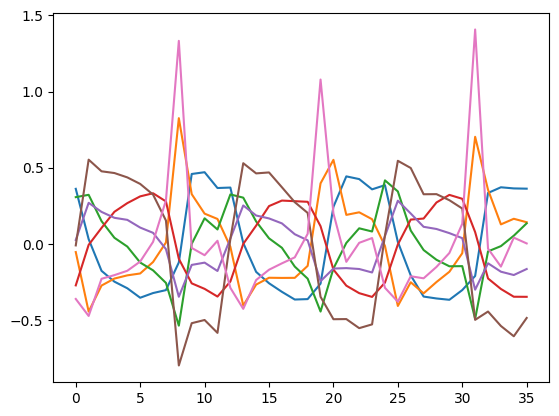

In [18]:
plt.plot(np.arange(36), data)
plt.show()

In [19]:
best_AIC = np.inf
best_sol = None
best_p, best_q = None, None
p_max = 3
q_max = 3

#Find the best model according to AIC
for p in range(1, p_max + 1):
    for q in range(1, q_max + 1):
        print(f'Iterating with p = {p}, q = {q}')
        model = VARMAX(data, order=(p,1, q),trend='c').fit(maxiter=10000)
        AIC = model.aic
        print(f'AIC is {AIC}')
        if AIC < best_AIC:
            print('Better found')
            best_AIC = AIC
            best_p = p
            best_q = q
best_model = VARMAX(data, order=(best_p,1, best_q),trend='c').fit(maxiter=10000)
print(best_model.summary())

Iterating with p = 1, q = 1


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


KeyboardInterrupt: 

In [21]:
best_AIC = np.inf
best_sol = None
best_p, best_q = None, None
p_max = 3
q_max = 3

#Find the best model according to AIC
for p in range(1, p_max + 1):
    for q in range(1, q_max + 1):
        print(f'Iterating with p = {p}, q = {q}')
        model = ARIMA(data['2'], order=(p,0, q),trend='c').fit()
        AIC = model.aic
        print(f'AIC is {AIC}')
        if AIC < best_AIC:
            print('Better found')
            best_AIC = AIC
            best_p = p
            best_q = q
best_model = ARIMA(data['2'], order=(best_p,0, best_q),trend='c').fit()
print(best_model.summary())

Iterating with p = 1, q = 1
AIC is -38.44873357295372
Better found
Iterating with p = 1, q = 2
AIC is -36.46929218502154
Iterating with p = 1, q = 3
AIC is -38.28334831063496
Iterating with p = 2, q = 1


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AIC is -46.721915059809334
Better found
Iterating with p = 2, q = 2
AIC is -34.448743560255984
Iterating with p = 2, q = 3
AIC is -55.72480318824172
Better found
Iterating with p = 3, q = 1


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AIC is -47.411561080512435
Iterating with p = 3, q = 2
AIC is -42.78896679358815
Iterating with p = 3, q = 3
AIC is -55.65764682809855
                               SARIMAX Results                                
Dep. Variable:                      2   No. Observations:                   36
Model:                 ARIMA(2, 0, 3)   Log Likelihood                  34.862
Date:                Mon, 13 Apr 2026   AIC                            -55.725
Time:                        14:35:11   BIC                            -44.640
Sample:                             0   HQIC                           -51.856
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.003     -0.089      0.929      -0.006       0.

In [32]:
model = ARIMA(data['2'], order=(30, 0, 0)).fit()
print(model.summary())

/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      2   No. Observations:                   36
Model:                ARIMA(30, 0, 0)   Log Likelihood                  56.880
Date:                Mon, 13 Apr 2026   AIC                            -49.759
Time:                        14:43:58   BIC                              0.914
Sample:                             0   HQIC                           -32.073
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0061      0.094      0.065      0.948      -0.179       0.191
ar.L1         -0.8763      7.578     -0.116      0.908     -15.730      13.977
ar.L2         -0.4349      8.578     -0.051      0.9

/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(best_p, best_q)